In [26]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [27]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], errors="ignore", inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")


In [28]:
dataset["hour_sin"] = dataset["timestamp"].apply(lambda x: np.sin(2 * np.pi * x.hour / 24.0))
dataset["hour_cos"] = dataset["timestamp"].apply(lambda x: np.cos(2 * np.pi * x.hour / 24.0))

In [ ]:
FEATURE_COLS = ["pm2_5 (μg/m³)", "hour_sin", "hour_cos"]
TARGET_COL = "pm2_5 (μg/m³)"
N_FEATURES = len(FEATURE_COLS)
TARGET_SCALER_IDX = FEATURE_COLS.index(TARGET_COL)


df = dataset[FEATURE_COLS + ["timestamp"]].copy()
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("h") 

INPUT_WINDOW = 24 *3
OUTPUT_WINDOW = 24
BATCH_SIZE = 64

train_raw = df.loc[:"2024-12-31 23:00:00", FEATURE_COLS].copy()
test_raw = df.loc["2025-01-01 00:00:00":"2025-12-31 23:00:00", FEATURE_COLS].copy()

scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw), columns=FEATURE_COLS, index=train_raw.index)
test_scaled = pd.DataFrame(scaler.transform(test_raw), columns=FEATURE_COLS, index=test_raw.index)


def create_clock_anchored_sequences(df_scaled, feature_cols, target_col, input_w, output_w):
    X, Y = [], []
    feature_matrix = df_scaled[feature_cols].values
    target_vector = df_scaled[target_col].values
    
    for i in range(len(df_scaled) - input_w - output_w + 1):
        X.append(feature_matrix[i : i + input_w, :])
        Y.append(target_vector[i + input_w : i + input_w + output_w])
        
    return np.array(X), np.array(Y)

X_train, y_train = create_clock_anchored_sequences(train_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
X_test, y_test = create_clock_anchored_sequences(test_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)

In [30]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [31]:
import torch
import torch.nn as nn

class TransformerLSTMModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers, hidden_dim, num_lstm_layers, output_dim, seq_len, dropout=0.1):
        super(TransformerLSTMModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        x = self.input_projection(src)
        x = x + self.pos_encoder[:, :src.size(1), :]
        x = self.dropout(x)
        transformer_out = self.transformer_encoder(x)
        lstm_out, (hn, cn) = self.lstm(transformer_out)
        out = lstm_out[:, -1, :]
        predictions = self.fc(self.dropout(out))
        return predictions

In [32]:
import optuna
import torch.optim as optim
import torch.nn as nn
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def objective(trial):
    # 1. Define the Hyperparameter Search Space
    d_model = trial.suggest_categorical("d_model", [32, 64, 128, 256])
    nhead = trial.suggest_categorical("nhead", [2, 4, 8])
    
    if d_model % nhead != 0:
        raise optuna.exceptions.TrialPruned()
        
    num_transformer_layers = trial.suggest_int("num_transformer_layers", 1, 4)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128, 256])
    num_lstm_layers = trial.suggest_int("num_lstm_layers", 1, 4)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    # 2. Instantiate Model
    trial_model = TransformerLSTMModel(
        input_dim=N_FEATURES, 
        seq_len=INPUT_WINDOW, 
        d_model=d_model, 
        nhead=nhead, 
        num_transformer_layers=num_transformer_layers, 
        hidden_dim=hidden_dim,  
        num_lstm_layers=num_lstm_layers, 
        dropout=dropout, 
        output_dim=OUTPUT_WINDOW
    ).to(DEVICE)
    
    trial_optimizer = optim.Adam(trial_model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    epochs = 40
    
    total_train_loss = 0.0
    total_val_loss = 0.0
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        trial_model.train()
        epoch_train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            
            trial_optimizer.zero_grad(set_to_none=True)
            predictions = trial_model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            
            nn.utils.clip_grad_norm_(trial_model.parameters(), max_norm=1.0)
            trial_optimizer.step()
            
            epoch_train_loss += loss.item() * batch_x.size(0)
            
        total_train_loss = epoch_train_loss / len(train_loader.dataset)
            
        # --- VALIDATION PHASE ---
        trial_model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(DEVICE, non_blocking=True)
                batch_y = batch_y.to(DEVICE, non_blocking=True)
                val_predictions = trial_model(batch_x)
                val_loss = criterion(val_predictions, batch_y)
                epoch_val_loss += val_loss.item() * batch_x.size(0)
                
        total_val_loss = epoch_val_loss / len(test_loader.dataset)
        
        trial.report(total_val_loss, epoch)
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    generalization_gap = abs(total_val_loss - total_train_loss)
    overfitting_penalty = 0.2 * generalization_gap
    optimization_metric = total_val_loss + overfitting_penalty

    return optimization_metric

# Initialize Study with the Pruner
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.SuccessiveHalvingPruner(
        min_resource=20,
        reduction_factor=2
    )
)

study.optimize(objective, n_trials=40)

print("\n--- Optimization Complete ---")
print("Best Trial Value (Metric + Penalty):", study.best_trial.value)
print("Best Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

[I 2026-06-29 13:56:14,736] A new study created in memory with name: no-name-864e5ede-2e6d-467c-8b98-c8352dbc21ed
[I 2026-06-29 13:58:35,019] Trial 0 finished with value: 0.0032451984834073475 and parameters: {'d_model': 256, 'nhead': 4, 'num_transformer_layers': 1, 'hidden_dim': 32, 'num_lstm_layers': 1, 'dropout': 0.26410651194784307, 'lr': 0.0025351393280563924}. Best is trial 0 with value: 0.0032451984834073475.
[I 2026-06-29 14:02:23,811] Trial 1 pruned. 
[I 2026-06-29 14:06:18,410] Trial 2 finished with value: 0.00283785196422329 and parameters: {'d_model': 32, 'nhead': 4, 'num_transformer_layers': 3, 'hidden_dim': 32, 'num_lstm_layers': 1, 'dropout': 0.12662598795231955, 'lr': 0.0001619349125041573}. Best is trial 2 with value: 0.00283785196422329.
[I 2026-06-29 14:08:03,513] Trial 3 pruned. 
[I 2026-06-29 14:14:44,934] Trial 4 finished with value: 0.0044729745886218615 and parameters: {'d_model': 32, 'nhead': 2, 'num_transformer_layers': 4, 'hidden_dim': 256, 'num_lstm_layers':


--- Optimization Complete ---
Best Trial Value (Metric + Penalty): 0.002546078568317803
Best Hyperparameters:
  d_model: 32
  nhead: 4
  num_transformer_layers: 3
  hidden_dim: 32
  num_lstm_layers: 1
  dropout: 0.07823495350545936
  lr: 0.00022829607620292633


In [33]:
from pytorch_lightning.callbacks import Callback

class SimpleLossTracker(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is not None:
            self.train_losses.append(train_loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

loss_tracker = SimpleLossTracker()

In [34]:
def inverse_transform_target(scaled_data, scaler, target_idx, n_features):
    flat_data = scaled_data.flatten()
    dummy = np.zeros((len(flat_data), n_features))
    dummy[:, target_idx] = flat_data
    unscaled_dummy = scaler.inverse_transform(dummy)
    return unscaled_dummy[:, target_idx].reshape(scaled_data.shape)

In [35]:
best_params = study.best_trial.params
best_params["num_transformer_layers"] = 1

In [36]:
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as sklearn_r2


print("\n--- Best Hyperparameters Found ---")
for key, value in best_params.items():
    print(f"  {key}: {value}")

final_model = TransformerLSTMModel(
    input_dim=N_FEATURES, 
    seq_len=INPUT_WINDOW, 
    d_model=best_params["d_model"], 
    nhead=best_params["nhead"], 
    num_transformer_layers=best_params["num_transformer_layers"], 
    hidden_dim=best_params["hidden_dim"],  
    num_lstm_layers=best_params["num_lstm_layers"], 
    dropout=best_params["dropout"], 
    output_dim=OUTPUT_WINDOW
).to(DEVICE)

final_optimizer = optim.Adam(final_model.parameters(), lr=best_params["lr"])
criterion = nn.MSELoss()

hist_train = []
hist_val = []
FINAL_EPOCHS = 60

print(f"\nTraining final optimized model for {FINAL_EPOCHS} epochs...")
for epoch in range(FINAL_EPOCHS):
    final_model.train()
    epoch_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE, non_blocking=True)
        batch_y = batch_y.to(DEVICE, non_blocking=True)

        final_optimizer.zero_grad(set_to_none=True)
        predictions = final_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        
        nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        final_optimizer.step()
        
        epoch_train_loss += loss.item() * batch_x.size(0)

    total_train_loss = epoch_train_loss / len(train_loader.dataset)
    hist_train.append(total_train_loss)

    final_model.eval()
    epoch_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            
            val_predictions = final_model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            
            epoch_val_loss += val_loss.item() * batch_x.size(0)
            
    total_val_loss = epoch_val_loss / len(test_loader.dataset)
    hist_val.append(total_val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} | Train Loss (MSE): {total_train_loss:.6f} | Val Loss (MSE): {total_val_loss:.6f}")



--- Best Hyperparameters Found ---
  d_model: 32
  nhead: 4
  num_transformer_layers: 1
  hidden_dim: 32
  num_lstm_layers: 1
  dropout: 0.07823495350545936
  lr: 0.00022829607620292633

Training final optimized model for 60 epochs...
Epoch 01/60 | Train Loss (MSE): 0.005448 | Val Loss (MSE): 0.003480
Epoch 10/60 | Train Loss (MSE): 0.003010 | Val Loss (MSE): 0.002849
Epoch 20/60 | Train Loss (MSE): 0.002936 | Val Loss (MSE): 0.002765
Epoch 30/60 | Train Loss (MSE): 0.002870 | Val Loss (MSE): 0.002739
Epoch 40/60 | Train Loss (MSE): 0.002784 | Val Loss (MSE): 0.002771
Epoch 50/60 | Train Loss (MSE): 0.002646 | Val Loss (MSE): 0.002996
Epoch 60/60 | Train Loss (MSE): 0.002518 | Val Loss (MSE): 0.002790


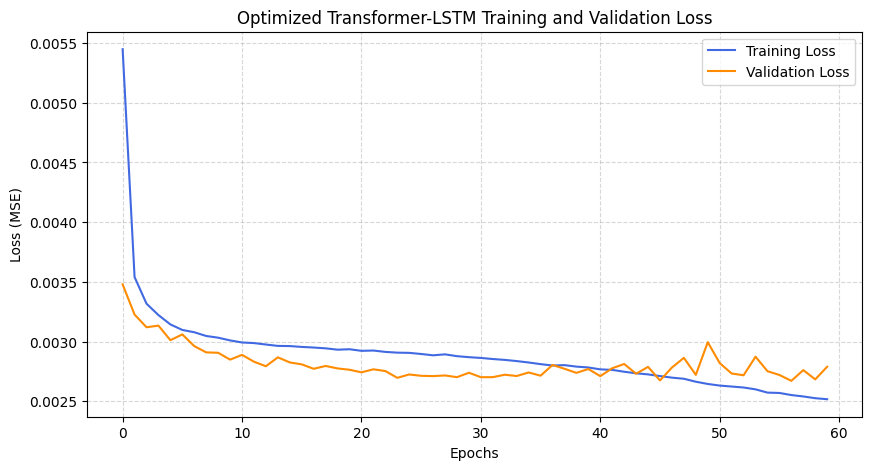

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(hist_train, label='Training Loss', color='royalblue')
plt.plot(hist_val, label='Validation Loss', color='darkorange')
plt.title('Optimized Transformer-LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

In [38]:
final_model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        
        preds = final_model(batch_x).cpu().numpy()
        actuals = batch_y.numpy()
        
        all_predictions.append(preds)
        all_ground_truth.append(actuals)

all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

true_predictions_all = inverse_transform_target(all_predictions, scaler, TARGET_SCALER_IDX, N_FEATURES)
true_ground_truth_all = inverse_transform_target(all_ground_truth, scaler, TARGET_SCALER_IDX, N_FEATURES)

global_mae = mean_absolute_error(true_ground_truth_all.flatten(), true_predictions_all.flatten())
global_rmse = np.sqrt(mean_squared_error(true_ground_truth_all.flatten(), true_predictions_all.flatten()))
global_r2 = sklearn_r2(true_ground_truth_all.flatten(), true_predictions_all.flatten())

ground_truth_mean = np.mean(true_ground_truth_all)
mae_percentage = (global_mae / ground_truth_mean)
rmse_percentage = (global_rmse / ground_truth_mean)

print(f"\n=== Final Transformer-LSTM Benchmark Results ===")
print(f"Global R² Score     : {global_r2:.4f}")
print(f"Global MAE          : {global_mae:.4f} μg/m³")
print(f"Global RMSE         : {global_rmse:.4f} μg/m³")
print(f"MAE% (Normalized)   : {mae_percentage:.2f}")
print(f"RMSE% (Normalized)  : {rmse_percentage:.2f}")


=== Final Transformer-LSTM Benchmark Results ===
Global R² Score     : 0.6234
Global MAE          : 2.8119 μg/m³
Global RMSE         : 3.9561 μg/m³
MAE% (Normalized)   : 0.30
RMSE% (Normalized)  : 0.42


In [39]:
import plotly.graph_objects as go

sample_indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
num_samples = len(sample_indices)

fig = go.Figure()
buttons = []

for idx, sample_idx in enumerate(sample_indices):
    # Pull directly from pre-computed, inverted arrays to avoid loop overhead
    true_actual = true_ground_truth_all[sample_idx]
    true_pred = true_predictions_all[sample_idx]
    
    start_timestamp_idx = INPUT_WINDOW + sample_idx
    window_timestamps = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[
        start_timestamp_idx : start_timestamp_idx + OUTPUT_WINDOW
    ]
    time_labels = [str(t).split()[1][:5] for t in window_timestamps]
    date_str = str(window_timestamps[0]).split()[0]
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_actual,
        mode='lines+markers',
        name=f'Actual PM2.5 ({date_str})',
        line=dict(color='seagreen', width=3),
        visible=(idx == 0)
    ))
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_pred,
        mode='lines+markers',
        name=f'Transformer-LSTM Forecast ({date_str})',
        line=dict(color='darkorange', width=2, dash='dash'),
        visible=(idx == 0)
    ))
    
    visibility_mask = [False] * (num_samples * 2)
    visibility_mask[idx * 2] = True
    visibility_mask[idx * 2 + 1] = True
    
    buttons.append(dict(
        label=f"Horizon: {date_str}",
        method="update",
        args=[
            {"visible": visibility_mask},
            {"title": f"<b>Transformer-LSTM Performance Horizon: {date_str}</b>"} 
        ]
    ))

initial_date_str = str(df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[INPUT_WINDOW]).split()[0]

fig.update_layout(
    title=dict(
        text=f'<b>Transformer-LSTM Performance Horizon: {initial_date_str}</b>',
        x=0.5,
        font=dict(size=16)
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    xaxis=dict(title='Hour of Day (24h Forecast Horizon)', showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='PM2.5 Concentration (μg/m³)', showgrid=True, gridcolor='lightgray'),
    template='plotly_white',
    hovermode='x unified',
    height=550,
    width=900,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()

In [ ]:
with open("4.5transformer_lstm_optimized.pkl", "wb") as file:
    pickle.dump(final_model, file)

Evaluation of saved model that I lost the moment it was run but saved the model, best model yet

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], errors="ignore", inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")


In [3]:
dataset["hour_sin"] = dataset["timestamp"].apply(lambda x: np.sin(2 * np.pi * x.hour / 24.0))
dataset["hour_cos"] = dataset["timestamp"].apply(lambda x: np.cos(2 * np.pi * x.hour / 24.0))

In [4]:
FEATURE_COLS = ["pm2_5 (μg/m³)", "hour_sin", "hour_cos"]
TARGET_COL = "pm2_5 (μg/m³)"
N_FEATURES = len(FEATURE_COLS)
TARGET_SCALER_IDX = FEATURE_COLS.index(TARGET_COL)


df = dataset[FEATURE_COLS + ["timestamp"]].copy()
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("h") 

INPUT_WINDOW = 24 *3
OUTPUT_WINDOW = 24
BATCH_SIZE = 64

train_raw = df.loc[:"2024-12-31 23:00:00", FEATURE_COLS].copy()
test_raw = df.loc["2025-01-01 00:00:00":"2025-12-31 23:00:00", FEATURE_COLS].copy()

scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw), columns=FEATURE_COLS, index=train_raw.index)
test_scaled = pd.DataFrame(scaler.transform(test_raw), columns=FEATURE_COLS, index=test_raw.index)


def create_clock_anchored_sequences(df_scaled, feature_cols, target_col, input_w, output_w):
    X, Y = [], []
    feature_matrix = df_scaled[feature_cols].values
    target_vector = df_scaled[target_col].values
    
    for i in range(len(df_scaled) - input_w - output_w + 1):
        X.append(feature_matrix[i : i + input_w, :])
        Y.append(target_vector[i + input_w : i + input_w + output_w])
        
    return np.array(X), np.array(Y)

X_train, y_train = create_clock_anchored_sequences(train_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
X_test, y_test = create_clock_anchored_sequences(test_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)

In [5]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
import torch
import torch.nn as nn

class TransformerLSTMModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers, hidden_dim, num_lstm_layers, output_dim, seq_len, dropout=0.1):
        super(TransformerLSTMModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        x = self.input_projection(src)
        x = x + self.pos_encoder[:, :src.size(1), :]
        x = self.dropout(x)
        transformer_out = self.transformer_encoder(x)
        lstm_out, (hn, cn) = self.lstm(transformer_out)
        out = lstm_out[:, -1, :]
        predictions = self.fc(self.dropout(out))
        return predictions

In [7]:
# ========================================
# EVALUATION ONLY - Load and Test CPU Model
# ========================================
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as sklearn_r2

DEVICE = torch.device('cpu')  # Force CPU evaluation

# Load the saved model
with open("models_saved/4.5transformer_lstm_optimized_cpu.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Move model to CPU and set to evaluation mode
final_model = loaded_model.to(DEVICE)

In [8]:
def inverse_transform_target(scaled_data, scaler, target_idx, n_features):
    flat_data = scaled_data.flatten()
    dummy = np.zeros((len(flat_data), n_features))
    dummy[:, target_idx] = flat_data
    unscaled_dummy = scaler.inverse_transform(dummy)
    return unscaled_dummy[:, target_idx].reshape(scaled_data.shape)


=== Final Transformer-LSTM Benchmark Results ===
Global R² Score     : 0.5965
Global MAE          : 2.3718 μg/m³
Global RMSE         : 3.6598 μg/m³
MAE% (Normalized)   : 0.32
RMSE% (Normalized)  : 0.49


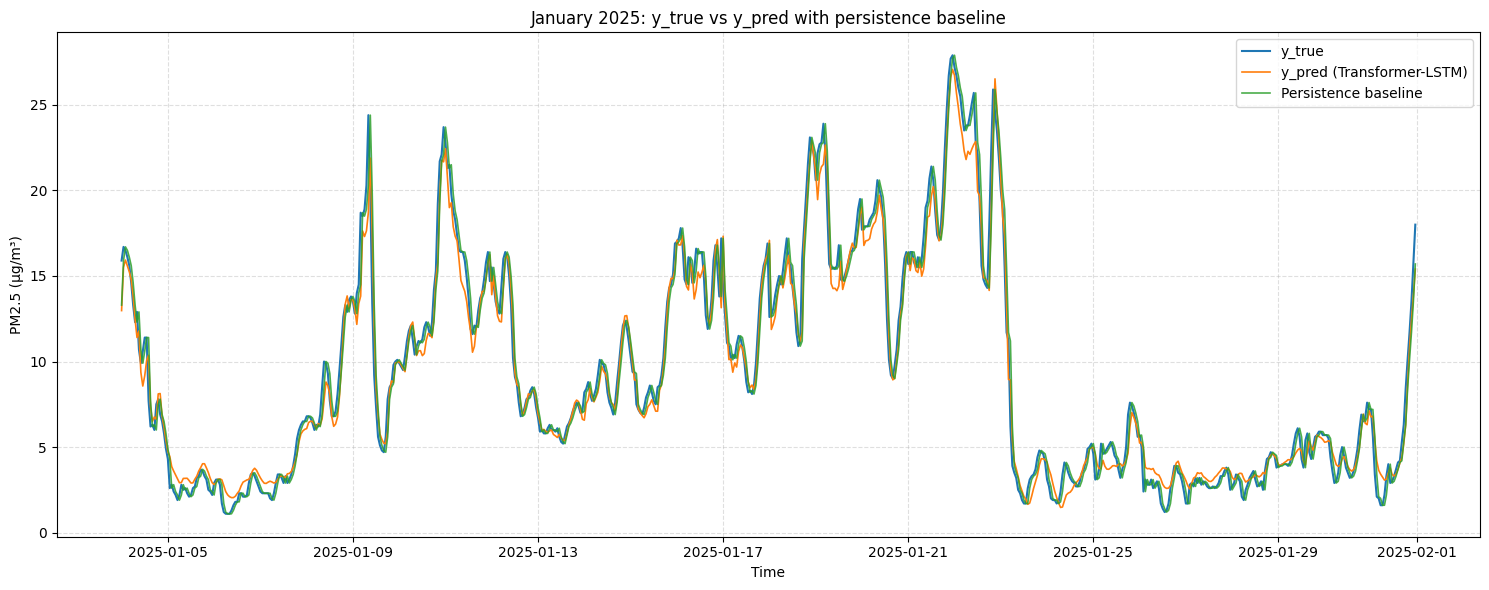

In [9]:
final_model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        
        preds = final_model(batch_x).cpu().numpy()
        actuals = batch_y.numpy()
        
        all_predictions.append(preds)
        all_ground_truth.append(actuals)

all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

true_predictions_all = inverse_transform_target(all_predictions, scaler, TARGET_SCALER_IDX, N_FEATURES)
true_ground_truth_all = inverse_transform_target(all_ground_truth, scaler, TARGET_SCALER_IDX, N_FEATURES)

global_mae = mean_absolute_error(true_ground_truth_all.flatten(), true_predictions_all.flatten())
global_rmse = np.sqrt(mean_squared_error(true_ground_truth_all.flatten(), true_predictions_all.flatten()))
global_r2 = sklearn_r2(true_ground_truth_all.flatten(), true_predictions_all.flatten())

ground_truth_mean = np.mean(true_ground_truth_all)
mae_percentage = (global_mae / ground_truth_mean)
rmse_percentage = (global_rmse / ground_truth_mean)

print(f"\n=== Final Transformer-LSTM Benchmark Results ===")
print(f"Global R² Score     : {global_r2:.4f}")
print(f"Global MAE          : {global_mae:.4f} μg/m³")
print(f"Global RMSE         : {global_rmse:.4f} μg/m³")
print(f"MAE% (Normalized)   : {mae_percentage:.2f}")
print(f"RMSE% (Normalized)  : {rmse_percentage:.2f}")

# Plot aligned one-hour-ahead predictions for January 2025.
plot_timestamps = test_scaled.index[INPUT_WINDOW:INPUT_WINDOW + len(all_ground_truth)]
plot_mask = (plot_timestamps >= "2025-01-01") & (plot_timestamps <= "2025-01-31 23:00:00")

plot_true = true_ground_truth_all[:, 0][plot_mask]
plot_pred = true_predictions_all[:, 0][plot_mask]
persistence_scaled = X_test[:, -1, TARGET_SCALER_IDX]
plot_persistence = inverse_transform_target(
    persistence_scaled, scaler, TARGET_SCALER_IDX, N_FEATURES
)[plot_mask]
plot_timestamps = plot_timestamps[plot_mask]

plt.figure(figsize=(15, 6))
plt.plot(plot_timestamps, plot_true, label="y_true", linewidth=1.5)
plt.plot(plot_timestamps, plot_pred, label="y_pred (Transformer-LSTM)", linewidth=1.2)
plt.plot(plot_timestamps, plot_persistence, label="Persistence baseline", linewidth=1.2, alpha=0.85)
plt.title("January 2025: y_true vs y_pred with persistence baseline")
plt.xlabel("Time")
plt.ylabel("PM2.5 (μg/m³)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [10]:
import plotly.graph_objects as go

sample_indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
num_samples = len(sample_indices)

fig = go.Figure()
buttons = []

for idx, sample_idx in enumerate(sample_indices):
    # Pull directly from pre-computed, inverted arrays to avoid loop overhead
    true_actual = true_ground_truth_all[sample_idx]
    true_pred = true_predictions_all[sample_idx]
    
    start_timestamp_idx = INPUT_WINDOW + sample_idx
    window_timestamps = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[
        start_timestamp_idx : start_timestamp_idx + OUTPUT_WINDOW
    ]
    time_labels = [str(t).split()[1][:5] for t in window_timestamps]
    date_str = str(window_timestamps[0]).split()[0]
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_actual,
        mode='lines+markers',
        name=f'Actual PM2.5 ({date_str})',
        line=dict(color='seagreen', width=3),
        visible=(idx == 0)
    ))
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_pred,
        mode='lines+markers',
        name=f'Transformer-LSTM Forecast ({date_str})',
        line=dict(color='darkorange', width=2, dash='dash'),
        visible=(idx == 0)
    ))
    
    visibility_mask = [False] * (num_samples * 2)
    visibility_mask[idx * 2] = True
    visibility_mask[idx * 2 + 1] = True
    
    buttons.append(dict(
        label=f"Horizon: {date_str}",
        method="update",
        args=[
            {"visible": visibility_mask},
            {"title": f"<b>Transformer-LSTM Performance Horizon: {date_str}</b>"} 
        ]
    ))

initial_date_str = str(df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[INPUT_WINDOW]).split()[0]

fig.update_layout(
    title=dict(
        text=f'<b>Transformer-LSTM Performance Horizon: {initial_date_str}</b>',
        x=0.5,
        font=dict(size=16)
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    xaxis=dict(title='Hour of Day (24h Forecast Horizon)', showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='PM2.5 Concentration (μg/m³)', showgrid=True, gridcolor='lightgray'),
    template='plotly_white',
    hovermode='x unified',
    height=550,
    width=900,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()